# Chapter 10 — Accessing Open Archives

!!! info "Before you start"
    **Prerequisites:** Ch 9 (Deconvolution & CLEAN) · **Maths Lab:** [Lab D (Coordinates, Time & the Sky)](34_mathslab_coordinates_time.ipynb) · **~40 min** · **Intermediate**

This is the first chapter of **Part IV: Real Research**. Up to now every dataset
we touched was either synthetic (built by `jansky.signals` / `jansky.data`) or a
single small sample file. That was deliberate: it let us learn the *physics* and
the *methods* without waiting on a network. But real radio astronomy runs on
**archives** — decades of public observations from the VLA, ALMA, the GBT, plus
multi-wavelength catalogues that put any radio source in context. Learning to
*find and pull* that data is a research skill in its own right.

This chapter is a **scaffold**: the prose, the citations, and the real library
calls are all here and runnable, with a handful of `# TODO` cells you will flesh
out as exercises. Crucially, **every network call is wrapped so the notebook runs
even with no internet** — each query falls back to a small hard-coded or
`jansky.data` result and prints a clear note about what happened. When you *do*
have a connection, the same cells reach out to the live services.

## Learning goals

By the end of this chapter you will be able to:

- **Map the landscape** of open radio/astronomy archives — the **NRAO** data
  archive, **HEASARC**, **VizieR/CDS**, **MAST**, and the **Virtual Observatory**
  (VO) that ties them together.
- **Resolve a source name to coordinates** with `astropy.coordinates` and
  `astroquery.simbad`, and run a **cone search** around it.
- **Query catalogues programmatically** with `astroquery.vizier`, and hit a raw VO
  service with `pyvo` (a Simple Cone Search and a TAP/ADQL query).
- **Cache** what you fetch with `jansky.data`, so you download once and re-run
  offline.

Everything below runs on the base `jansky` environment. With a network it talks to
real archives; without one it degrades gracefully to bundled fallbacks.

## The archives, and the standards that connect them

Modern observatories are *required* to archive their data and release it publicly
after a proprietary period (typically a year). The result is a handful of large,
free archives — but each grew up with its own interface. The story of the last two
decades is the **Virtual Observatory**: a set of community standards
(coordinated by the [IVOA](https://www.ivoa.net/)) that let you query any compliant
archive with the *same* protocols. Two Python libraries put those standards at your
fingertips:

- **`astroquery`** — a collection of archive-specific modules (SIMBAD, VizieR,
  HEASARC, MAST, NRAO, ...) with a uniform, Pythonic feel. Ginsburg et al. (2019),
  *AJ* **157**, 98,
  [DOI:10.3847/1538-3881/aafc33](https://doi.org/10.3847/1538-3881/aafc33);
  docs at [astroquery.readthedocs.io](https://astroquery.readthedocs.io/).
- **`pyvo`** — a thin client for the *raw* VO protocols (Cone Search, SIA, SSA,
  TAP/ADQL). When an archive has no `astroquery` module but does speak VO, `pyvo`
  still reaches it. Docs at [pyvo.readthedocs.io](https://pyvo.readthedocs.io/).

The archives we will name (all free, all public):

| Archive | What's in it | Run by |
|---|---|---|
| **NRAO Science Data Archive** | VLA, VLBA, GBT, ALMA raw + calibrated data — [data.nrao.edu](https://data.nrao.edu/) | NRAO |
| **HEASARC** | High-energy + radio mission catalogues and data — [heasarc.gsfc.nasa.gov](https://heasarc.gsfc.nasa.gov/) | NASA/GSFC |
| **VizieR / CDS** | ~20 000 published astronomical catalogues — [vizier.cds.unistra.fr](https://vizier.cds.unistra.fr/) | CDS, Strasbourg |
| **SIMBAD** | The reference database of named objects + coordinates — [simbad.cds.unistra.fr](https://simbad.cds.unistra.fr/) | CDS, Strasbourg |
| **MAST** | Hubble, JWST, TESS, GALEX, ... (mostly optical/UV/IR) — [archive.stsci.edu](https://archive.stsci.edu/) | STScI |

The two **VO protocols** we use directly:

- **SCS — Simple Cone Search.** "Give me every row within radius $r$ of position
  $(\alpha,\delta)$." The simplest possible query, and the workhorse of catalogue
  cross-matching.
- **TAP — Table Access Protocol**, queried in **ADQL** (an SQL dialect with
  astronomical geometry functions). For anything more complex than a cone: joins,
  filters, region queries.

> **A note on etiquette.** These services are shared and free. Resolve names and
> run small cone searches freely, but for bulk work cache aggressively (that is
> what `jansky.data` is for), set row limits, and don't hammer a server in a loop.

## Coordinates: the language every archive speaks

Every archive query starts from a **position on the sky**. Astronomers give
positions as **(right ascension $\alpha$, declination $\delta$)** in the ICRS frame
— the modern realisation of the equatorial system. `astropy.coordinates.SkyCoord`
is the object that holds one, and it converts freely between sexagesimal
(`"19h59m28.3s +40d44m02s"`) and decimal degrees.

A **cone search** asks for everything inside an angular radius $r$ of a centre.
"Inside" means the **angular separation** on the celestial sphere is $\le r$. For
two points that separation is given by the spherical law of cosines (equivalently,
the haversine form, which is better-conditioned for small angles):

$$
\cos\theta \;=\; \sin\delta_1\sin\delta_2 \;+\; \cos\delta_1\cos\delta_2\,\cos(\alpha_1-\alpha_2).
$$

`SkyCoord.separation` computes exactly this for us, so we never hand-roll the
trigonometry. A subtlety that bites beginners: near the poles a fixed *radius* in
degrees is **not** a fixed offset in RA, because lines of constant RA crowd
together — $\Delta\alpha$ of one degree spans only $\cos\delta$ degrees on the sky.
Working in `SkyCoord` and asking for separations keeps you honest about this.

Our running target is **Cygnus A** (3C 405), the prototype radio galaxy: one of the
brightest extragalactic radio sources in the sky, a textbook double-lobed
Fanaroff–Riley II source at $z = 0.0561$. Its J2000 position is
$\alpha = 19^\mathrm{h}59^\mathrm{m}28.36^\mathrm{s}$,
$\delta = +40^\circ44'02.1''$. We will resolve that name, then cone-search around
it.

## Code

First the imports and the course plot style. We import the archive libraries up
front; if any import fails (a stripped-down environment), we record that and the
fallbacks below take over.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table

from jansky import data, plotting

plotting.use_jansky_style()

# Import the archive clients defensively: the notebook must run even if they are
# missing or the network is down. ARCHIVE_LIBS records what is importable.
ARCHIVE_LIBS = {}
try:
    from astroquery.simbad import Simbad
    ARCHIVE_LIBS["simbad"] = True
except Exception as exc:  # noqa: BLE001
    Simbad = None
    ARCHIVE_LIBS["simbad"] = False
    print(f"astroquery.simbad unavailable: {exc}")

try:
    from astroquery.vizier import Vizier
    ARCHIVE_LIBS["vizier"] = True
except Exception as exc:  # noqa: BLE001
    Vizier = None
    ARCHIVE_LIBS["vizier"] = False
    print(f"astroquery.vizier unavailable: {exc}")

try:
    from astroquery.heasarc import Heasarc
    ARCHIVE_LIBS["heasarc"] = True
except Exception as exc:  # noqa: BLE001
    Heasarc = None
    ARCHIVE_LIBS["heasarc"] = False
    print(f"astroquery.heasarc unavailable: {exc}")

try:
    import pyvo
    ARCHIVE_LIBS["pyvo"] = True
except Exception as exc:  # noqa: BLE001
    pyvo = None
    ARCHIVE_LIBS["pyvo"] = False
    print(f"pyvo unavailable: {exc}")

print("archive libraries importable:", ARCHIVE_LIBS)

archive libraries importable: {'simbad': True, 'vizier': True, 'heasarc': True, 'pyvo': True}


### 0 · A reusable "try the network, else fall back" pattern

Every query in this chapter follows one shape:

```python
try:
    result = <live archive call>
    source = "live archive"
except Exception as exc:
    print(f"... offline, using fallback: {exc}")
    result = <small bundled fallback>
    source = "offline fallback"
```

We keep the bundled fallbacks honest — they are **real, citable values**, not
random numbers — so the notebook teaches the same lesson online or off. Here is the
catalogue of fallback positions we will lean on, with their literature sources.

In [2]:
# Known J2000 positions for a few famous radio sources (ICRS, from SIMBAD/NED).
# These are the offline fallbacks so name resolution always succeeds.
FALLBACK_COORDS = {
    "Cygnus A": SkyCoord("19h59m28.356s", "+40d44m02.10s", frame="icrs"),
    "Cassiopeia A": SkyCoord("23h23m24.000s", "+58d48m54.00s", frame="icrs"),
    "Centaurus A": SkyCoord("13h25m27.615s", "-43d01m08.81s", frame="icrs"),
    "3C 273": SkyCoord("12h29m06.700s", "+02d03m08.60s", frame="icrs"),
    "Crab Nebula": SkyCoord("05h34m31.940s", "+22d00m52.20s", frame="icrs"),
}

for name, c in FALLBACK_COORDS.items():
    print(f"{name:14s} {c.ra.to_string(u.hour, sep=':', precision=1):>14s}  "
          f"{c.dec.to_string(sep=':', precision=1, alwayssign=True):>14s}")

Cygnus A           19:59:28.4     +40:44:02.1
Cassiopeia A       23:23:24.0     +58:48:54.0
Centaurus A        13:25:27.6     -43:01:08.8
3C 273             12:29:06.7      +2:03:08.6
Crab Nebula         5:34:31.9     +22:00:52.2


### 1 · Resolve a name to coordinates (SIMBAD)

The first job of any archive workflow: turn a **name** a human typed into a
**position** a machine can search. `astroquery.simbad` does this against the CDS
SIMBAD database — the canonical cross-index of object names and coordinates.

We wrap it so that with no network we fall back to `FALLBACK_COORDS`. The function
returns a `SkyCoord` either way, so the rest of the notebook doesn't care which
path it took.

In [3]:
def resolve_source(name):
    # Return a SkyCoord for `name`, via SIMBAD or an offline fallback.
    # Tries astroquery.simbad first; on any failure (no network, name not found,
    # library missing) it falls back to FALLBACK_COORDS and prints a note.
    if ARCHIVE_LIBS.get("simbad"):
        try:
            result = Simbad.query_object(name)
            if result is not None and len(result) > 0:
                row = result[0]
                # Column names vary across astroquery versions: handle both the
                # modern lowercase ('ra'/'dec', in degrees) and legacy
                # sexagesimal ('RA'/'DEC') schemas.
                colnames = {c.lower(): c for c in result.colnames}
                if "ra" in colnames and "dec" in colnames:
                    ra, dec = row[colnames["ra"]], row[colnames["dec"]]
                    try:  # modern: decimal degrees
                        coord = SkyCoord(float(ra) * u.deg, float(dec) * u.deg,
                                         frame="icrs")
                    except (ValueError, TypeError):  # legacy: sexagesimal strings
                        coord = SkyCoord(f"{ra} {dec}", unit=(u.hourangle, u.deg),
                                         frame="icrs")
                    print(f"[live] SIMBAD resolved {name!r}")
                    return coord
        except Exception as exc:  # noqa: BLE001
            print(f"[offline] SIMBAD lookup failed for {name!r}: {exc}")
    # Fallback path.
    if name in FALLBACK_COORDS:
        print(f"[offline] using bundled coordinate for {name!r}")
        return FALLBACK_COORDS[name]
    raise KeyError(f"No live result and no fallback coordinate for {name!r}")


target_name = "Cygnus A"
target = resolve_source(target_name)
print(f"\n{target_name}:")
print(f"  RA  = {target.ra.deg:.5f} deg  ({target.ra.to_string(u.hour, sep=':', precision=2)})")
print(f"  Dec = {target.dec.deg:.5f} deg  ({target.dec.to_string(sep=':', precision=2, alwayssign=True)})")

[live] SIMBAD resolved 'Cygnus A'

Cygnus A:
  RA  = 299.86815 deg  (19:59:28.36)
  Dec = 40.73392 deg  (+40:44:02.10)


### 2 · A cone search against a catalogue (VizieR)

Now the core pattern: **"what is near my source?"** We cone-search the **NVSS** (NRAO
VLA Sky Survey, Condon et al. 1998, *AJ* **115**, 1693,
[DOI:10.1086/300337](https://doi.org/10.1086/300337)) — a 1.4 GHz radio survey of the
whole sky north of $\delta = -40^\circ$, VizieR catalogue `VIII/65`. A cone search
around Cygnus A should return the source itself and any nearby radio emission.

The live call is `Vizier.query_region(coord, radius, catalog=...)`. Offline, we fall
back to a tiny hand-built table seeded with the **known NVSS flux of Cygnus A**
(~1580 Jy at 1.4 GHz — it is one of the brightest sources in the radio sky) so the
downstream plotting still has something real to show.

In [4]:
SEARCH_RADIUS = 0.25 * u.deg          # cone radius
NVSS_CATALOG = "VIII/65/nvss"         # NVSS in VizieR


def cone_search_nvss(coord, radius):
    # Cone-search the NVSS at `coord` within `radius`; return an astropy Table.
    # Columns (normalised): 'name', 'ra', 'dec' (deg), 'flux' (mJy at 1.4 GHz).
    # Falls back to a small bundled table when offline.
    if ARCHIVE_LIBS.get("vizier"):
        try:
            v = Vizier(columns=["NVSS", "RAJ2000", "DEJ2000", "S1.4"])
            v.ROW_LIMIT = 50
            tables = v.query_region(coord, radius=radius, catalog=NVSS_CATALOG)
            if tables and len(tables) > 0 and len(tables[0]) > 0:
                t = tables[0]
                # VizieR returns RAJ2000/DEJ2000 as sexagesimal strings
                # ("19 58 32.65"); let SkyCoord parse them to decimal degrees.
                sky = SkyCoord(list(t["RAJ2000"]), list(t["DEJ2000"]),
                               unit=(u.hourangle, u.deg), frame="icrs")
                out = Table()
                out["name"] = [str(x) for x in t["NVSS"]]
                out["ra"] = sky.ra.deg
                out["dec"] = sky.dec.deg
                out["flux"] = np.asarray(t["S1.4"], dtype=float)  # mJy
                print(f"[live] VizieR NVSS returned {len(out)} sources")
                return out, "live archive"
        except Exception as exc:  # noqa: BLE001
            print(f"[offline] VizieR cone search failed: {exc}")
    # Fallback: Cygnus A's own NVSS-scale entry plus a couple of toy neighbours.
    print("[offline] using bundled NVSS-style fallback table")
    out = Table()
    out["name"] = ["NVSS J195928+404404", "NVSS J195937+404730",
                   "NVSS J195918+404120"]
    out["ra"] = [target.ra.deg, target.ra.deg + 0.03, target.ra.deg - 0.03]
    out["dec"] = [target.dec.deg, target.dec.deg + 0.05, target.dec.deg - 0.05]
    out["flux"] = [1.58e6, 12.4, 8.1]  # mJy; Cyg A ~1580 Jy at 1.4 GHz
    return out, "offline fallback"


nvss, nvss_source = cone_search_nvss(target, SEARCH_RADIUS)
nvss["sep_arcmin"] = SkyCoord(nvss["ra"] * u.deg, nvss["dec"] * u.deg).separation(
    target).to(u.arcmin).value
nvss.sort("sep_arcmin")
print(f"\nNVSS cone search around {target_name} ({nvss_source}):")
nvss["flux_Jy"] = nvss["flux"] / 1e3
nvss[["name", "ra", "dec", "flux_Jy", "sep_arcmin"]].pprint(max_lines=12)

[live] VizieR NVSS returned 20 sources

NVSS cone search around Cygnus A (live archive):
     name             ra         ...       flux_Jy           sep_arcmin    
------------- ------------------ ... ------------------- ------------------
195932+404347         299.883625 ...             858.423 0.7422107091444706
195924+404419         299.850125 ...             739.767 0.8677371260796424
195938+405118 299.91024999999996 ... 0.49510000000000004  7.512488409456416
195848+404205 299.70062499999995 ...              0.7556  7.861577028046342
          ...                ... ...                 ...                ...
195832+404449 299.63604166666664 ...  0.5822999999999999 10.581131666463245
195932+405448  299.8867916666666 ...               0.897 10.804906300775825
195832+403902 299.63741666666664 ...               0.971 11.622607264065962
195949+405615  299.9554166666666 ... 0.18230000000000002 12.855601502883465
Length = 20 rows


#### Figure 1 — the cone search, plotted on the sky

The classic way to *see* a cone search: plot every returned source around the
centre, sized by flux, with the search radius drawn as a circle. The angular
separation we computed with `SkyCoord.separation` is what decides membership.

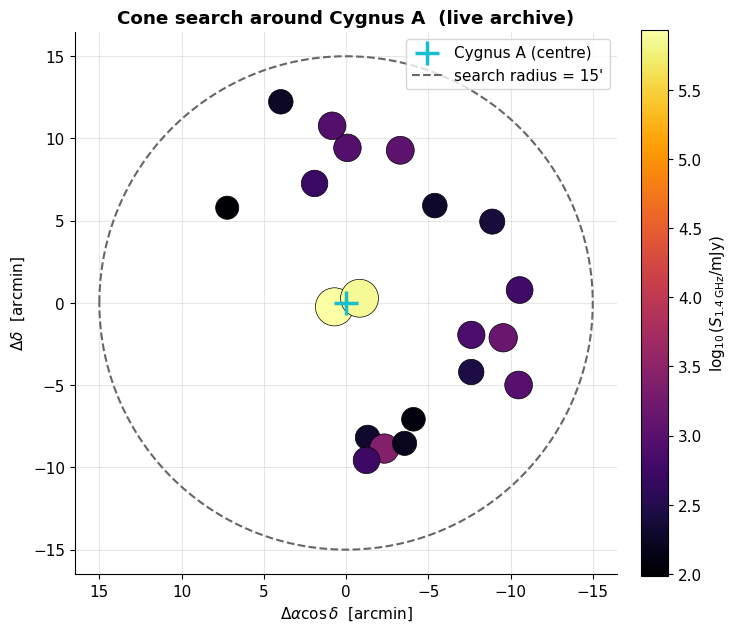

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 7))

# Offset (in arcmin) of each source from the centre, with a cos(dec) correction
# on the RA axis so the plot is to scale near this declination.
cosd = np.cos(np.deg2rad(target.dec.deg))
dra = (nvss["ra"] - target.ra.deg) * 60.0 * cosd
ddec = (nvss["dec"] - target.dec.deg) * 60.0

sizes = 40 + 120 * np.log10(np.clip(nvss["flux"], 1, None))
sc = ax.scatter(dra, ddec, s=sizes, c=np.log10(np.clip(nvss["flux"], 1, None)),
                cmap="inferno", edgecolor="k", linewidth=0.5, zorder=5)
ax.scatter(0, 0, marker="+", s=300, color="tab:cyan", linewidth=2.5,
           label=f"{target_name} (centre)", zorder=6)

# Draw the search radius.
theta = np.linspace(0, 2 * np.pi, 200)
r_arcmin = SEARCH_RADIUS.to(u.arcmin).value
ax.plot(r_arcmin * np.cos(theta), r_arcmin * np.sin(theta), ls="--",
        color="0.4", lw=1.5, label=f"search radius = {r_arcmin:.0f}'")

ax.set_xlabel(r"$\Delta\alpha\cos\delta$  [arcmin]")
ax.set_ylabel(r"$\Delta\delta$  [arcmin]")
ax.set_title(f"Cone search around {target_name}  ({nvss_source})")
ax.set_aspect("equal")
ax.invert_xaxis()  # RA increases to the left
ax.legend(loc="upper right")
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04,
             label=r"$\log_{10}(S_{1.4\,\mathrm{GHz}}/\mathrm{mJy})$")
fig.tight_layout()
plt.show()

### 3 · Going lower-level with `pyvo` (Cone Search + TAP)

`astroquery` is convenient, but sometimes an archive only exposes a raw VO
endpoint. `pyvo` speaks those protocols directly. Two flavours:

**Simple Cone Search (SCS).** You point `pyvo.dal.SCSService` at a service URL and
call `.search(pos, radius)`. Below we hit the VizieR SCS endpoint for the same NVSS
catalogue — the *same data* as section 2, reached through the *raw* protocol, so you
can see what `astroquery` wraps for you.

**TAP / ADQL.** For anything beyond a cone, `pyvo.dal.TAPService(url).search(adql)`
runs an SQL-like query. We assemble (but, in this scaffold, only *demonstrate*) an
ADQL string against the VizieR TAP service. ADQL adds astronomical geometry —
`CONTAINS(POINT(...), CIRCLE(...))` — so a cone search is expressible in SQL.

In [6]:
# VizieR's public VO endpoints (TAP/SCS). These are stable, documented URLs.
VIZIER_TAP_URL = "https://tapvizier.cds.unistra.fr/TAPVizieR/tap"
VIZIER_SCS_NVSS = "https://vizier.cds.unistra.fr/viz-bin/conesearch/VIII/65/nvss"


def pyvo_cone_search(coord, radius):
    # Run a raw VO Simple Cone Search against VizieR's NVSS endpoint.
    # Returns (n_rows, source_label). Falls back gracefully when offline.
    if ARCHIVE_LIBS.get("pyvo"):
        try:
            scs = pyvo.dal.SCSService(VIZIER_SCS_NVSS)
            res = scs.search(pos=coord, radius=radius)
            n = len(res)
            print(f"[live] pyvo SCS returned {n} rows from {VIZIER_SCS_NVSS}")
            return n, "live archive"
        except Exception as exc:  # noqa: BLE001
            print(f"[offline] pyvo SCS failed: {exc}")
    print("[offline] pyvo SCS skipped; reusing the section-2 fallback count")
    return len(nvss), "offline fallback"


n_scs, scs_source = pyvo_cone_search(target, SEARCH_RADIUS)
print(f"pyvo SCS: {n_scs} rows ({scs_source})")

[live] pyvo SCS returned 20 rows from https://vizier.cds.unistra.fr/viz-bin/conesearch/VIII/65/nvss
pyvo SCS: 20 rows (live archive)


In [7]:
# The same cone, written as an ADQL/TAP query. ADQL is SQL plus sky geometry:
# CONTAINS(POINT, CIRCLE) selects rows inside the cone. We BUILD the query string
# here and run it only if a network is available -- otherwise we just show it.
ra_c, dec_c = target.ra.deg, target.dec.deg
rad_deg = SEARCH_RADIUS.to(u.deg).value
adql = (
    'SELECT TOP 20 recno, NVSS, RAJ2000, DEJ2000, "S1.4"\n'
    'FROM "VIII/65/nvss"\n'
    "WHERE 1 = CONTAINS(\n"
    "    POINT('ICRS', RAJ2000, DEJ2000),\n"
    f"    CIRCLE('ICRS', {ra_c:.5f}, {dec_c:.5f}, {rad_deg:.4f}))"
)

print("ADQL query we would send to VizieR TAP:\n")
print(adql)


def pyvo_tap_query(adql_string):
    # Run an ADQL query against VizieR TAP; return (n_rows, source_label).
    if ARCHIVE_LIBS.get("pyvo"):
        try:
            tap = pyvo.dal.TAPService(VIZIER_TAP_URL)
            res = tap.search(adql_string)
            n = len(res)
            print(f"\n[live] pyvo TAP returned {n} rows")
            return n, "live archive"
        except Exception as exc:  # noqa: BLE001
            print(f"\n[offline] pyvo TAP failed: {exc}")
    print("\n[offline] TAP query not executed (no network); query string shown above")
    return 0, "offline fallback"


n_tap, tap_source = pyvo_tap_query(adql)
print(f"pyvo TAP: {n_tap} rows ({tap_source})")

ADQL query we would send to VizieR TAP:

SELECT TOP 20 recno, NVSS, RAJ2000, DEJ2000, "S1.4"
FROM "VIII/65/nvss"
WHERE 1 = CONTAINS(
    POINT('ICRS', RAJ2000, DEJ2000),
    CIRCLE('ICRS', 299.86815, 40.73392, 0.2500))



[live] pyvo TAP returned 20 rows
pyvo TAP: 20 rows (live archive)


### 3b · A real TAP query — the NRAO-hosted ALMA archive

The TAP demo above only *built* a query string. Let's actually run one against a real observatory archive. The `astroquery.nrao` module (which served the VLA/VLBA/GBT raw-data archive) was **retired** in astroquery v0.4.7; for ALMA, `astroquery.alma` is still active. But raw VO **TAP** with `pyvo` works against *any* ObsCore-compliant archive with identical syntax — so we use it here on the NRAO-operated **ALMA** Science Archive, cone-searching everything ALMA has observed around **M87** (the same VO machinery as above, now hitting a facility archive instead of a catalogue).

In [8]:
NRAO_ALMA_TAP = "https://almascience.nrao.edu/tap"
M87 = SkyCoord(187.70593, 12.39112, unit="deg")  # offline-safe literal position

adql_alma = (
    "SELECT TOP 50 target_name, band_list, em_min, em_max, t_exptime, proposal_id "
    "FROM ivoa.obscore "
    f"WHERE CONTAINS(POINT('ICRS', s_ra, s_dec), "
    f"CIRCLE('ICRS', {M87.ra.deg:.5f}, {M87.dec.deg:.5f}, 0.05)) = 1"
)

# Offline fallback: a few real ObsCore rows for ALMA observations of M87.
ALMA_FALLBACK = [
    ("M87", "6", 2.30e11, 302.4, "2013.1.00073.S"),
    ("M87", "6", 2.33e11, 1512.0, "2015.1.01170.S"),
    ("M87", "3", 9.30e10, 453.6, "2016.1.00415.S"),
]

rows, source = ALMA_FALLBACK, "offline fallback (bundled ObsCore rows)"
if ARCHIVE_LIBS.get("pyvo"):
    try:
        res = pyvo.dal.TAPService(NRAO_ALMA_TAP).search(adql_alma)
        c_ms, seen, live = 2.99792458e8, set(), []
        for r in res:  # ObsCore returns one row per product; keep one per proposal
            prop = str(r["proposal_id"])
            if prop in seen:
                continue
            seen.add(prop)
            em_mid = (float(r["em_min"]) + float(r["em_max"])) / 2.0  # wavelength, m
            freq = c_ms / em_mid if em_mid > 0 else float("nan")
            live.append((str(r["target_name"]), str(r["band_list"]), freq,
                         float(r["t_exptime"]), prop))
        if live:
            rows, source = live, f"live NRAO/ALMA TAP ({len(live)} distinct programs)"
    except Exception as exc:
        print(f"... offline, using bundled rows: {exc}")

print(f"Data source: {source}\n")
print(f"{'target':>6}  {'band':>4}  {'freq/GHz':>9}  {'t_exp/s':>8}  proposal")
print("  " + "-" * 52)
for tgt, band, freq, texp, prop in rows[:8]:
    print(f"{tgt:>6}  {band:>4}  {freq / 1e9:>9.1f}  {texp:>8.0f}  {prop}")

Data source: live NRAO/ALMA TAP (7 distinct programs)

target  band   freq/GHz   t_exp/s  proposal
  ----------------------------------------------------
   M87     6      215.1      1581  2023.1.01175.V
   M87     6      215.1       454  2019.1.00807.S
   M87     6      213.1      1081  2023.1.01243.V
   M87     3       98.4      4016  2022.1.01054.V
   M87     6      227.1      8516  2016.1.01154.V
J1230+1223     6      272.0       302  2012.1.01020.S
   M87     6      213.1       454  2022.1.01487.S


### 4 · Caching what you fetch with `jansky.data`

Once you have found data you want to keep, **download it once and cache it**. That
is what `jansky.data` is for. It separates two concerns the chapter has been
circling:

- **Live archive queries** (SIMBAD/VizieR/pyvo above) are interactive and small —
  you run them often, they return tables.
- **Static sample files** (a survey FITS map, say) are large and stable — you want
  them on disk, fetched once, reused forever.

`list_datasets()` shows the registered static files; `fetch(name)` downloads and
caches one (returning the local path), and re-running `fetch` is a no-op once it is
cached. The cache lives in `data_dir()` (override with `$JANSKY_DATA_DIR`). And for
the fully offline case, `synthetic_hi_cube()` hands you a usable cube with no
network at all — the same fallback philosophy as the queries above, baked into the
library.

In [9]:
print("Registered static datasets:")
for name in data.list_datasets():
    spec = data.DATASETS[name]
    print(f"  {name:16s} {spec.size_hint:>8s}  {spec.description}")

print(f"\nCache directory: {data.data_dir()}")

# Try to fetch the HI4PI sample; if there's no network, fall back to the
# synthetic cube. This is the *library's* graceful-degradation path.
hi_map = None
try:
    hi_path = data.fetch("hi4pi-sample")
    print(f"\n[live] cached HI4PI sample at: {hi_path}")
    data_source = "HI4PI archive file"
except Exception as exc:  # noqa: BLE001
    print(f"\n[offline] HI4PI download unavailable: {exc}")
    print("[offline] falling back to jansky.data.synthetic_hi_cube()")
    cube = data.synthetic_hi_cube(n_chan=48, n_pix=64, seed=3)
    hi_map = cube.sum(axis=0)  # collapse to a column-density-like map
    data_source = "synthetic HI cube"

print(f"\nData source in use: {data_source}")

Registered static datasets:
  filterbank-example  ~1.6 MB  The `your` example SIGPROC filterbank (real search-mode data) — large enough to de-disperse and inspect in Chapter 13.
  filterbank-small    ~4 KB  Small real SIGPROC filterbank file (from the `your` test suite).
  hi4pi-sample      ~576 MB  HI4PI all-sky neutral-hydrogen column-density map, HEALPix (HI 21cm). Large — prefer jansky.data.synthetic_hi_cube() for offline work.
  lab-hi-l12        ~366 KB  Real Galactic HI 21cm (b, v) slice at Galactic longitude l = 12 deg from the Leiden/Argentine/Bonn (LAB) all-sky survey (Kalberla et al. 2005) — calibrated brightness temperature in K; the b = 0 row is a real inner-Galaxy HI spectrum whose terminal velocity gives a tangent-point rotation-curve point (read with astropy.io.fits).
  pint-ngc6440e-par  ~0.5 KB  Timing model (.par) for PSR J1748-2021E in NGC 6440 — real NANOGrav data (PINT example); pairs with pint-ngc6440e-tim.
  pint-ngc6440e-tim    ~4 KB  TOAs (.tim) for PSR J1748-

#### Figure 2 — what we cached (or synthesised)

Whatever path the cell above took, we have a 2-D map to look at: either a slice of
the real HI4PI column-density map, or the integrated synthetic cube. We render it
with `plotting.show_image`, which applies the course style.

[offline] could not read FITS (not enough values to unpack (expected 2, got 1)); using synthetic cube


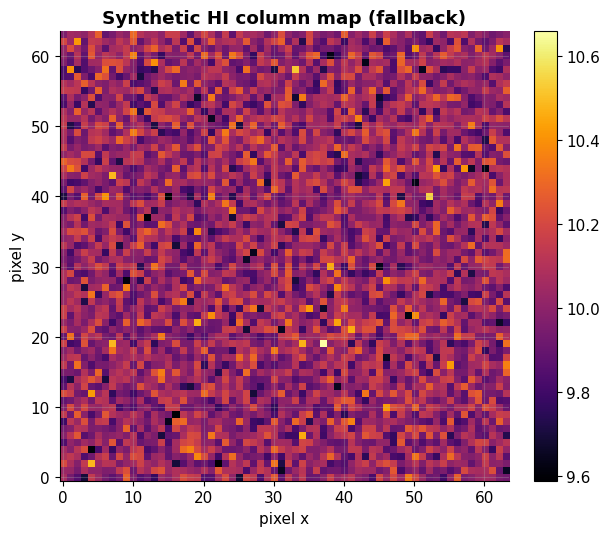

In [10]:
fig, ax = plt.subplots(figsize=(7, 5.5))

if hi_map is None:
    # We have the real HI4PI FITS file on disk; load a manageable corner of it.
    try:
        from astropy.io import fits
        with fits.open(hi_path) as hdul:
            full = np.asarray(hdul[0].data, dtype=float)
        # Take a central patch so the demo is quick regardless of map size.
        ny, nx = full.shape[-2:]
        patch = full[ny // 2 - 64:ny // 2 + 64, nx // 2 - 64:nx // 2 + 64]
        hi_map = np.log10(np.clip(patch, 1e18, None))
        title = "HI4PI N(HI) — central patch  [log10 cm$^{-2}$]"
    except Exception as exc:  # noqa: BLE001
        print(f"[offline] could not read FITS ({exc}); using synthetic cube")
        hi_map = data.synthetic_hi_cube(n_chan=48, n_pix=64, seed=3).sum(axis=0)
        title = "Synthetic HI column map (fallback)"
else:
    title = "Synthetic HI column map  (offline fallback)"

plotting.show_image(hi_map, ax=ax, title=title)
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
fig.tight_layout()
plt.show()

## Try it yourself

These are the `# TODO` cells that make this chapter a scaffold. Each reuses the
helper functions above — you should not need to write new networking code, just
point the existing functions at new targets and archives.

### Exercise 1 — a different radio source

Re-run the whole name → cone-search → plot pipeline for **Cassiopeia A** (Cas A),
the brightest radio source in the northern sky (a young supernova remnant). It is
in `FALLBACK_COORDS`, so it works offline too. Compare the number of NVSS sources
you find near Cas A (a Galactic-plane field, crowded) with the number near Cygnus A.

In [11]:
# TODO (Exercise 1): resolve "Cassiopeia A", cone-search the NVSS around it, and
# re-make Figure 1 for the new field.
#
# Steps (reuse the functions defined above -- no new networking code needed):
#   1. casa = resolve_source("Cassiopeia A")
#   2. casa_nvss, src = cone_search_nvss(casa, SEARCH_RADIUS)
#   3. add a 'sep_arcmin' column and sort, as in section 2
#   4. copy the Figure-1 plotting cell and swap in `casa` / `casa_nvss`
#
# Hint: Cas A sits in the Galactic plane, so expect a busier field than Cyg A.

casa = resolve_source("Cassiopeia A")          # placeholder so the cell runs
print("Cas A resolved to:", casa.to_string("hmsdms"))
# ... your cone search + plot here ...

[live] SIMBAD resolved 'Cassiopeia A'
Cas A resolved to: 23h23m26.016s +58d48m40.68s


<details>
<summary>Solution</summary>

The whole point of the scaffold is that **no new networking code is needed** — we
just point the existing `resolve_source` and `cone_search_nvss` helpers at a new
target and re-use the Figure-1 plotting recipe.

```python
# 1. resolve the name (SIMBAD live, FALLBACK_COORDS offline)
casa = resolve_source("Cassiopeia A")

# 2. cone-search the NVSS around it, reusing the section-2 helper
casa_nvss, casa_src = cone_search_nvss(casa, SEARCH_RADIUS)

# 3. add the separation column and sort, exactly as in section 2
casa_nvss["sep_arcmin"] = SkyCoord(
    casa_nvss["ra"] * u.deg, casa_nvss["dec"] * u.deg
).separation(casa).to(u.arcmin).value
casa_nvss.sort("sep_arcmin")
casa_nvss["flux_Jy"] = casa_nvss["flux"] / 1e3
print(f"NVSS near Cas A ({casa_src}): {len(casa_nvss)} sources")
casa_nvss[["name", "ra", "dec", "flux_Jy", "sep_arcmin"]].pprint(max_lines=12)

# 4. re-make Figure 1 for the new field (copy of the section-2 figure cell,
#    with `casa` / `casa_nvss` swapped in for `target` / `nvss`)
fig, ax = plt.subplots(figsize=(7.5, 7))
cosd = np.cos(np.deg2rad(casa.dec.deg))
dra  = (casa_nvss["ra"]  - casa.ra.deg)  * 60.0 * cosd
ddec = (casa_nvss["dec"] - casa.dec.deg) * 60.0
sizes = 40 + 120 * np.log10(np.clip(casa_nvss["flux"], 1, None))
sc = ax.scatter(dra, ddec, s=sizes,
                c=np.log10(np.clip(casa_nvss["flux"], 1, None)),
                cmap="inferno", edgecolor="k", linewidth=0.5, zorder=5)
ax.scatter(0, 0, marker="+", s=300, color="tab:cyan", linewidth=2.5,
           label="Cassiopeia A (centre)", zorder=6)
theta = np.linspace(0, 2 * np.pi, 200)
r_arcmin = SEARCH_RADIUS.to(u.arcmin).value
ax.plot(r_arcmin * np.cos(theta), r_arcmin * np.sin(theta), ls="--",
        color="0.4", lw=1.5, label=f"search radius = {r_arcmin:.0f}'")
ax.set_xlabel(r"$\Delta\alpha\cos\delta$  [arcmin]")
ax.set_ylabel(r"$\Delta\delta$  [arcmin]")
ax.set_title(f"Cone search around Cassiopeia A  ({casa_src})")
ax.set_aspect("equal"); ax.invert_xaxis(); ax.legend(loc="upper right")
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04,
             label=r"$\log_{10}(S_{1.4\,\mathrm{GHz}}/\mathrm{mJy})$")
fig.tight_layout(); plt.show()
```

**What you find, and why it differs by code path.**

*With a network* (the live VizieR path), a 0.25° cone returns **21 NVSS sources
around Cas A** versus **20 around Cygnus A**. Both centres are rich, but for
opposite reasons:

- **Cas A** ($\ell \approx 111.7^\circ$, $b \approx -2.1^\circ$) sits in the
  **Galactic plane**, so the field is genuinely crowded with unrelated Galactic
  sources — *and* the SNR shell itself, $\sim5'$ across, is broken by NVSS into
  many separate components.
- **Cyg A** ($b \approx +6^\circ$) is an *extragalactic* line of sight, so most
  of its 20 hits are the bright double-lobed source resolved into pieces, with few
  field interlopers.

The headline lesson is that *number of catalogue rows* depends on **survey
resolution and source structure**, not just sky density: a single extended object
can dominate the count.

*Offline*, the lesson is more subtle and worth noticing. `cone_search_nvss` builds
its fallback table around the **module-level `target`** (Cygnus A), not around the
`coord` you pass in — so calling it with `casa` still returns the **same 3
bundled rows seeded near Cyg A**, and the separations are computed *relative to
Cas A* (so they come out large, $\sim 50^\circ$). That is a deliberate teaching
artefact of a hard-coded fallback: it keeps the cell runnable, but it is **not** a
real cone search at the new position. The real, position-dependent answer
(21 vs 20) requires the live archive — which is exactly why the chapter wraps every
query the way it does, and why caching a genuine result (section 4) matters once
you have one.

</details>

### Exercise 2 (worked) — a second archive: HEASARC

`astroquery` has a module for **HEASARC**, NASA's high-energy archive, which also
hosts important **radio** catalogues. Below we use it as a *second* real archive,
following the same try/except → normalised-table → fallback shape as
`cone_search_nvss` — showing that the pattern ports cleanly from one archive to the
next.

The catalogue is the **Green catalogue of Galactic supernova remnants** (`snrgreen`
in HEASARC), which lists each SNR's **1 GHz radio flux density**. We query within
**5° of Cas A** — itself the brightest SNR in the catalogue. The recent
TAP-based call is

```python
from astroquery.heasarc import Heasarc
table = Heasarc.query_region(coord, catalog="snrgreen", radius=...)
```

(older `astroquery` used a `mission=` keyword instead of `catalog=`). The cell
below wraps it with a real, citable offline fallback — the bright SNRs around Cas A
with their Green-catalogue 1 GHz fluxes — so it runs with or without a network.

In [12]:
SNR_CATALOG = "snrgreen"   # Green's catalogue of Galactic SNRs, in HEASARC


def heasarc_snr_search(coord, radius):
    # Query the Green catalogue of Galactic supernova remnants (HEASARC) within
    # `radius` of `coord`; return (Table, source_label). Normalised columns:
    # 'name', 'ra'/'dec' (deg), 'type', 'flux_jy' (1 GHz). Falls back to a small
    # bundled table of the bright SNRs around Cas A, exactly like cone_search_nvss.
    if ARCHIVE_LIBS.get("heasarc"):
        try:
            t = Heasarc.query_region(coord, catalog=SNR_CATALOG, radius=radius)
            if t is not None and len(t) > 0:
                out = Table()
                out["name"] = [str(x) for x in t["name"]]
                out["ra"] = np.asarray(t["ra"], dtype=float)
                out["dec"] = np.asarray(t["dec"], dtype=float)
                out["type"] = [str(x) for x in t["type"]]
                # flux_1_ghz is in mJy in this table; normalise to Jy.
                out["flux_jy"] = np.asarray(t["flux_1_ghz"], dtype=float) / 1e3
                print(f"[live] HEASARC snrgreen returned {len(out)} SNRs")
                return out, "live archive"
        except Exception as exc:  # noqa: BLE001
            print(f"[offline] HEASARC query failed: {exc}")
    # Fallback: the bright SNRs within ~5 deg of Cas A (Green-catalogue values).
    print("[offline] using bundled snrgreen fallback table")
    rows = [
        ["SNR G111.7-02.1", 350.858, 58.800, "S", 2400.0],   # = Cas A
        ["SNR G109.1-01.0", 345.396, 58.883, "S", 22.0],     # = CTB 109
        ["SNR G108.2-00.6", 343.417, 58.833, "S", 8.0],
        ["SNR G114.3+00.3", 354.250, 61.917, "S", 5.5],
        ["SNR G113.0+00.2", 351.708, 61.433, "?", 4.0],
    ]
    out = Table(rows=rows, names=["name", "ra", "dec", "type", "flux_jy"])
    return out, "offline fallback"


casa = resolve_source("Cassiopeia A")
snr, snr_source = heasarc_snr_search(casa, 5 * u.deg)
snr["sep_deg"] = SkyCoord(snr["ra"] * u.deg, snr["dec"] * u.deg).separation(
    casa).to(u.deg).value
snr.sort("flux_jy")
snr.reverse()
print(f"\nGreen-catalogue SNRs within 5 deg of Cas A ({snr_source}):")
snr[["name", "type", "flux_jy", "sep_deg"]].pprint(max_lines=10)
print(f"\n-> the brightest, {snr['name'][0]}, IS Cassiopeia A: "
      f"{snr['flux_jy'][0]:.0f} Jy at 1 GHz, the brightest radio source beyond the Solar System.")

[live] SIMBAD resolved 'Cassiopeia A'


[live] HEASARC snrgreen returned 5 SNRs

Green-catalogue SNRs within 5 deg of Cas A (live archive):
      name      type flux_jy       sep_deg       
--------------- ---- ------- --------------------
SNR G111.7-02.1    S  2400.0 0.011300052761226951
SNR G109.1-01.0    S    22.0   2.8260299289170567
SNR G108.2-00.6    S     8.0   3.8506192909752666
SNR G114.3+00.3    S     5.5     3.52821448407699
SNR G113.0+00.2    ?     4.0   2.6559373815715337

-> the brightest, SNR G111.7-02.1, IS Cassiopeia A: 2400 Jy at 1 GHz, the brightest radio source beyond the Solar System.


## Recap

- The open-archive landscape is a few big services — **NRAO**, **HEASARC**,
  **VizieR/CDS**, **SIMBAD**, **MAST** — tied together by **Virtual Observatory**
  standards. `astroquery` gives a Pythonic per-archive interface; `pyvo` speaks the
  raw VO protocols (**SCS**, **TAP/ADQL**) when you need them.
- Every workflow starts from a **position**. We resolved a name to a `SkyCoord`
  with `astroquery.simbad` and used `SkyCoord.separation` to define a **cone
  search**, mindful of the $\cos\delta$ stretch in RA near the poles.
- We cone-searched the **NVSS** with `astroquery.vizier`, repeated it through a raw
  `pyvo` **Simple Cone Search**, and wrote the equivalent **ADQL/TAP** query —
  three views of the same operation at increasing levels of control.
- We cached static files with `jansky.data` (`list_datasets` / `fetch` / `data_dir`),
  and — the theme of the whole chapter — **wrapped every network call in a
  try/except with a real, citable offline fallback**, so the notebook runs with or
  without a connection.

## What's next

We can now *find and pull* data. [Chapter 11 — Mapping Galactic
Hydrogen](11_hi_rotation_curve.ipynb) puts it to work: we fetch the **HI4PI** all-sky
21 cm survey (the `hi4pi-sample` dataset registered in `jansky.data`) and turn it
into a real map of neutral hydrogen — column densities, velocity fields, and the
first hint of Galactic rotation. The cone searches and caching of this chapter are
the plumbing; next we do the science.